# Heart Attack Risk Models
- Trains and compares different models like logistic regression, random forest, gradient boosting, etc in terms of heart attack prediction(HadHeartAttack column in the dataset). 
- Uses Stratified 5 Fold cross validation from sklearn, and tracks the models with ML flow.
- f2 scoring since its better to have a false positive than a false negative

In [82]:
import pandas as pd
import mlflow
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, fbeta_score

### Load Processed Data
80/20 split for train/test

In [83]:
# load train and test vars
X_train = pd.read_csv('X_train_processed.csv')
X_test = pd.read_csv('X_test_processed.csv')

Y_train = pd.read_csv('y_train.csv').squeeze() # .squeeze to convert from table to a series
Y_test = pd.read_csv('y_test.csv').squeeze()

print(X_train.shape)
print(X_test.shape)

(196810, 50)
(49203, 50)


In [84]:
print(Y_train.value_counts(normalize=True)) # % of 0s and 1s
print(Y_train.value_counts())# # of 0s and 1s

HadHeartAttack
0    0.945389
1    0.054611
Name: proportion, dtype: float64
HadHeartAttack
0    186062
1     10748
Name: count, dtype: int64


### Feature Sets
full means all 50 columns

lifestyle takes all but the ones that are conditions out

FEATURE_SETS makes it so users on our app can pick and choose what they input, and arent forced to input 50 things about themselves

- use feature importance later to pick which factors to keep

In [85]:
#chest scan and a couple other conditions can be the result of a heart problem, so group them together
CONDITION_COLS = [c for c in X_train.columns if "Had" in c or "ChestScan" in c]

# new model trained on just the cols added
FEATURE_SETS = {
    "full": X_train.columns.tolist(), # all
    "lifestyle": [c for c in X_train.columns if c not in CONDITION_COLS], # all but conditions
}

print(CONDITION_COLS)
print(f'Full data: {len(FEATURE_SETS["full"])}, Lifestyle only: {len(FEATURE_SETS["lifestyle"])}')

['numeric__HadAngina', 'numeric__HadStroke', 'numeric__HadAsthma', 'numeric__HadSkinCancer', 'numeric__HadCOPD', 'numeric__HadDepressiveDisorder', 'numeric__HadKidneyDisease', 'numeric__HadArthritis', 'numeric__ChestScan']
Full data: 50, Lifestyle only: 41


### MLflow + CV Setup
- MLflow tracks every run we do and you can access it using: mlflow ui --backend-store-uri sqlite:///mlflow.db
- stratified 5 fold cv on the training set, so the model is trained 5 times with 5 chunks at the same rate

In [86]:
# every run gets stored in a local DB
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("heart_attack")

<Experiment: artifact_location=('file:c:/Users/gabeh/Documents/Coding Projects/ML '
 'Project/CS4342-Project/mlruns/1'), creation_time=1790798208516, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790798208516, lifecycle_stage='active', name='heart_attack', tags={}, trace_location=None, workspace='default'>

In [87]:
# 5 folds
# Each fold keeps the rate since its stratified
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# metrics
scoring = {
    "pr_auc": "average_precision",
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f2": make_scorer(fbeta_score, beta=2),
}

### Baselines
Baseline logistic regression for HadHeartAttack and evaluation

In [88]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate

In [89]:
results = [] # stores every model and feature set  with one row each

# evaluate functon makes it so we can pick a model, run cv on it, then log to MLFLOW and scores
def evaluate(model, name, feature_set):
    cols = FEATURE_SETS[feature_set]
    with mlflow.start_run(run_name=f"{name}_{feature_set}"):
        scores = cross_validate(model, X_train[cols], Y_train, cv=cv, scoring=scoring, n_jobs=-1)
        means = {m: scores[f"test_{m}"].mean() for m in scoring} # avg of the 5 folds
        mlflow.log_params({"model": name, "feature_set": feature_set})
        mlflow.log_metrics(means)
    row = {"model": name, "feature_set": feature_set}
    row.update(means)
    results.append(row)

In [90]:
# baseline dummy classifier
# balanced makes sure false negatives are penalized more
# increase max iterations 10x so that we make sure it will converge
for fs in FEATURE_SETS:
    evaluate(DummyClassifier(strategy="most_frequent"), "dummy", fs)
    evaluate(LogisticRegression(class_weight="balanced", max_iter=1000), "logreg", fs)

pd.DataFrame(results).round(3)

,model,feature_set,pr_auc,roc_auc,recall,precision,f2
0,dummy,full,0.055,0.500,0.000,0.000,0.000
1,logreg,full,0.405,0.889,0.769,0.213,0.505
2,dummy,lifestyle,0.055,0.500,0.000,0.000,0.000
3,logreg,lifestyle,0.216,0.826,0.778,0.142,0.410


### Tree Models
- hist gradient boosting makes trees that fix the last one's mistake
- random forest makes many trees that vote
- default settings here but tuning comes after

In [91]:
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier

# same as balanced but done every time for the sample of every tree
for fs in FEATURE_SETS:
    evaluate(HistGradientBoostingClassifier(class_weight="balanced", max_iter=500, random_state=42), "hgb", fs)
    evaluate(RandomForestClassifier(n_estimators=200, min_samples_leaf=5, class_weight="balanced_subsample", n_jobs=1, random_state=42), "rf", fs)

pd.DataFrame(results).round(3)

,model,feature_set,pr_auc,roc_auc,recall,precision,f2
0,dummy,full,0.055,0.500,0.000,0.000,0.000
1,logreg,full,0.405,0.889,0.769,0.213,0.505
2,dummy,lifestyle,0.055,0.500,0.000,0.000,0.000
3,logreg,lifestyle,0.216,0.826,0.778,0.142,0.410
4,hgb,full,0.415,0.889,0.782,0.203,0.498
5,rf,full,0.401,0.886,0.519,0.442,0.501
6,hgb,lifestyle,0.219,0.827,0.789,0.139,0.408
7,rf,lifestyle,0.210,0.821,0.260,0.255,0.259


### Hyperparameter Tuning
- RandomizedSearchCV tries random combos of settings and keeps the best by pr auc
- tuning logreg (baseline) and hgb (best model) on a 60k sample, then rerunning the best on the full training set

In [92]:
from scipy.stats import loguniform, randint
from sklearn.model_selection import RandomizedSearchCV, train_test_split

In [93]:
# smaller stratified sample so tuning is faster
X_tune, _, Y_tune, _ = train_test_split(X_train, Y_train, train_size=60_000, stratify=Y_train, random_state=42)

# model to tune, and the ranges to try for its settings
SEARCHES = {
    "logreg": (
        LogisticRegression(class_weight="balanced", max_iter=1000),
        {"C": loguniform(1e-3, 1e2)},
    ),
    "hgb": (
        HistGradientBoostingClassifier(class_weight="balanced", max_iter=500, random_state=42),
        {"learning_rate": loguniform(0.02, 0.3), "max_leaf_nodes": randint(15, 64), "min_samples_leaf": randint(20, 200)},
    ),
}

In [94]:
tuned_models = {}
for fs, cols in FEATURE_SETS.items():
    for name, (model, params) in SEARCHES.items():
        search = RandomizedSearchCV(model, params, n_iter=15, scoring="average_precision", cv=cv, n_jobs=-1, random_state=42)
        search.fit(X_tune[cols], Y_tune)
        print(name, fs, search.best_params_)

        # best settings rerun on the full training set so its comparable to the untuned ones
        tuned_models[(name, fs)] = search.best_estimator_
        evaluate(search.best_estimator_, f"{name}_tuned", fs)

pd.DataFrame(results).round(3)

logreg full {'C': np.float64(0.0019517224641449498)}
hgb full {'learning_rate': np.float64(0.09194081411309145), 'max_leaf_nodes': 23, 'min_samples_leaf': 109}
logreg lifestyle {'C': np.float64(0.0019517224641449498)}
hgb lifestyle {'learning_rate': np.float64(0.056343030242230155), 'max_leaf_nodes': 17, 'min_samples_leaf': 70}


,model,feature_set,pr_auc,roc_auc,recall,precision,f2
0,dummy,full,0.055,0.500,0.000,0.000,0.000
1,logreg,full,0.405,0.889,0.769,0.213,0.505
2,dummy,lifestyle,0.055,0.500,0.000,0.000,0.000
3,logreg,lifestyle,0.216,0.826,0.778,0.142,0.410
4,hgb,full,0.415,0.889,0.782,0.203,0.498
5,rf,full,0.401,0.886,0.519,0.442,0.501
6,hgb,lifestyle,0.219,0.827,0.789,0.139,0.408
7,rf,lifestyle,0.210,0.821,0.260,0.255,0.259
8,logreg_tuned,full,0.405,0.889,0.767,0.214,0.506
9,hgb_tuned,full,0.415,0.890,0.784,0.202,0.497


### Checkpoint Results
pick threshold that catches 80% of heart attacks and show the confusion matrix for it

In [95]:
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, precision_score, ConfusionMatrixDisplay

full threshold: 0.479 precision: 0.193


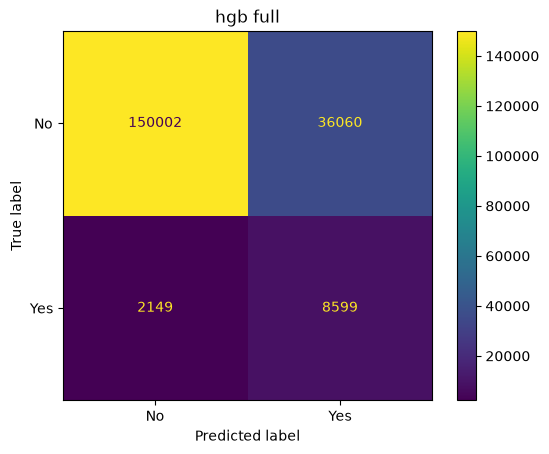

lifestyle threshold: 0.496 precision: 0.138


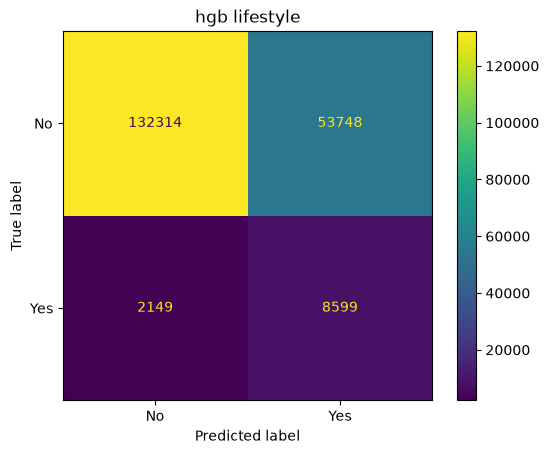

In [96]:
# hgb tuned was the best model on both feature sets
for fs, cols in FEATURE_SETS.items():
    proba = cross_val_predict(tuned_models[("hgb", fs)], X_train[cols], Y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

    # highest threshold where 80% of heart attacks still get flagged
    precision, recall, thresholds = precision_recall_curve(Y_train, proba)
    threshold = thresholds[recall[:-1] >= 0.80].max()
    pred = (proba >= threshold).astype(int)

    print(fs, "threshold:", round(threshold, 3), "precision:", round(precision_score(Y_train, pred), 3))
    ConfusionMatrixDisplay.from_predictions(Y_train, pred, display_labels=["No", "Yes"])
    plt.title(f"hgb {fs}")
    plt.show()